# Notebook 06 — Analysis of Notebook 05 Outputs

This notebook is the **analysis layer** for the Cu–Zr NCL workflow.

## Main goals
1. Load finished `ncl05_*` jobs from the pyiron project.
2. Build a clean inventory of available results by potential and job type.
3. Summarize static / EOS / MD outputs.
4. Compute structural observables:
   - final energies
   - equation-of-state summaries
   - RDF
   - MSD
   - energy and temperature traces
5. Keep the workflow reusable for future **A100-trained MACE** and **ACE** models.

## Notes
- This notebook is written to be **edited easily** rather than to be maximally compact.
- Several helper functions include fallbacks because pyiron / LAMMPS outputs can differ slightly across runs.
- If one section has no matching jobs yet, the notebook should fail gracefully and simply report that nothing was found.


In [1]:
# -----------------------------
# 0. User configuration
# -----------------------------
PROJECT_PATH = "../cu_zr_mlip_project"

# List the potential IDs exactly as they appear at the END of the job name.
# Longest names should come first because the parser uses suffix matching.
POTENTIAL_IDS = [
    "EAM_Mendelev_2019_CuZr",
    "2007_Mendelev-M-I_Cu-Zr_LAMMPS_ipr1",
    "MACE",
    "ACE",
]

# Which job-name prefix belongs to Notebook 05 outputs?
JOB_PREFIX = "ncl05_"

# Default analysis settings
RDF_RMAX = 8.0
RDF_BINS = 200
MAX_RDF_FRAMES = 10      # sample up to this many frames for trajectory RDF
MAX_MSD_FRAMES = None    # set to an integer if you want to truncate long trajectories

# Preferred tags / aliases used later when choosing representative jobs
TAG_ALIASES = {
    "static": ["sanity_static", "static"],
    "md": ["sanity_md", "short_md", "md", "nvt", "nve"],
    "eos": ["eos"],
    "melt_quench": ["melt_quench", "glass", "amorphous", "quench"],
}


In [2]:
# -----------------------------
# 1. Imports
# -----------------------------
import os
import re
import glob
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyiron_atomistics import Project

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True


## 2. Open project and load the job table


In [3]:
pr = Project(PROJECT_PATH)
pr


{'groups': [], 'nodes': ['mace_md_test', 'sanity_static_Cu_MACE', 'sanity_static_Cu_2007_MendelevmMmI_CumZr_LAMMPS_ipr1', 'sanity_static_Cu_EAM_Mendelev_2019_CuZr', 'ncl05_sanity_static_B2_MACE', 'ncl05_static_sanity_MACE', 'ncl05_melt_MACE', 'dev_melt_MACE', 'dev_eos_FCC_Cu_00_MACE', 'dev_eos_FCC_Cu_01_MACE', 'dev_eos_FCC_Cu_02_MACE', 'dev_eos_FCC_Cu_03_MACE', 'dev_eos_FCC_Cu_04_MACE', 'dev_eos_FCC_Cu_05_MACE', 'dev_eos_FCC_Cu_06_MACE', 'dev_eos_HCP_Zr_00_MACE', 'dev_eos_HCP_Zr_01_MACE', 'dev_eos_HCP_Zr_02_MACE', 'dev_eos_HCP_Zr_03_MACE', 'dev_eos_HCP_Zr_04_MACE', 'dev_eos_HCP_Zr_05_MACE', 'dev_eos_HCP_Zr_06_MACE', 'dev_eos_B2_CuZr_00_MACE', 'dev_eos_B2_CuZr_01_MACE', 'dev_eos_B2_CuZr_02_MACE', 'dev_eos_B2_CuZr_03_MACE', 'dev_eos_B2_CuZr_04_MACE', 'dev_eos_B2_CuZr_05_MACE', 'dev_eos_B2_CuZr_06_MACE', 'dev_eos_FCC_Cu_00_EAM_Mendelev_2019_CuZr', 'dev_eos_FCC_Cu_01_EAM_Mendelev_2019_CuZr', 'dev_eos_FCC_Cu_02_EAM_Mendelev_2019_CuZr', 'dev_eos_FCC_Cu_03_EAM_Mendelev_2019_CuZr', 'dev_eos_FC

In [26]:
jt = pr.job_table()
print(jt.to_string())
print(f"Total jobs in project: {len(jt)}")

if "job" not in jt.columns:
    raise KeyError("The project job table does not contain a 'job' column.")

jt05 = jt[jt["job"].astype(str).str.startswith(JOB_PREFIX)].copy()
print(f"Notebook 05 jobs found: {len(jt05)}")

jt05.head()


     id    status chemicalformula                                                      job                                                    subjob                     projectpath                   project                  timestart                   timestop  totalcputime                           computer hamilton hamversion parentid masterid
0     8  finished             Cu4                                             mace_md_test                                             /mace_md_test  /Users/ksenis/pyiron/projects/  CuZr/cu_zr_mlip_project/ 2026-02-22 14:28:23.581468 2026-02-22 14:39:01.988430         638.0  pyiron@MacBook-Air-Ksenia.local#1   Lammps        0.1     None     None
1    20  finished           Cu256                                    sanity_static_Cu_MACE                                    /sanity_static_Cu_MACE  /Users/ksenis/pyiron/projects/  CuZr/cu_zr_mlip_project/ 2026-02-27 17:20:26.489722 2026-02-27 17:20:30.068810           3.0  pyiron@MacBook-Air-Ksenia.lo

,id,status,chemicalformula,job,subjob,projectpath,project,timestart,timestop,totalcputime,computer,hamilton,hamversion,parentid,masterid
4,23,finished,Cu512Zr512,ncl05_sanity_static_B2_MACE,/ncl05_sanity_static_B2_MACE,/Users/ksenis/pyiron/projects/,CuZr/cu_zr_mlip_project/,2026-02-28 19:53:09.689644,2026-02-28 19:53:15.022465,5.0,pyiron@MacBook-Air-Ksenia.local#1,Lammps,0.1,None,None
5,27,finished,Cu512Zr512,ncl05_static_sanity_MACE,/ncl05_static_sanity_MACE,/Users/ksenis/pyiron/projects/,CuZr/cu_zr_mlip_project/,2026-03-02 17:55:04.186873,2026-03-02 17:55:08.096091,3.0,pyiron@MacBook-Air-Ksenia.local#1,Lammps,0.1,None,None
6,28,aborted,Cu512Zr512,ncl05_melt_MACE,/ncl05_melt_MACE,/Users/ksenis/pyiron/projects/,CuZr/cu_zr_mlip_project/,2026-03-02 17:55:08.119129,NaT,NaN,pyiron@MacBook-Air-Ksenia.local#1,Lammps,0.1,None,None


## 3. Parse job names robustly

The original notebook used:

```python
parts = jobname.split("_")
potid = parts[-1]
```

That breaks for potential IDs containing underscores.  
Here we instead match the **longest known potential suffix**.


In [5]:
def parse_ncl05(jobname: str, potential_ids=None, prefix=JOB_PREFIX):
    """Parse a job name of the form:
        ncl05_<tag>_<potid>

    where <potid> may itself contain underscores.

    Returns
    -------
    dict with keys:
        job_prefix, tag, potid, structure_hint
    """
    potential_ids = potential_ids or POTENTIAL_IDS

    if not isinstance(jobname, str) or not jobname.startswith(prefix):
        return {"job_prefix": None, "tag": None, "potid": None, "structure_hint": None}

    body = jobname[len(prefix):]

    # longest suffix match first
    for potid in sorted(potential_ids, key=len, reverse=True):
        suffix = "_" + potid
        if body.endswith(suffix):
            tag = body[:-len(suffix)]
            break
        if body == potid:
            tag = ""
            break
    else:
        # fallback: split only once from the right
        if "_" in body:
            tag, potid = body.rsplit("_", 1)
        else:
            tag, potid = body, None

    structure_hint = None
    for s in ["FCC_Cu", "HCP_Zr", "B2_CuZr", "amorphous", "glass"]:
        if s in tag:
            structure_hint = s
            break

    return {
        "job_prefix": prefix.rstrip("_"),
        "tag": tag,
        "potid": potid,
        "structure_hint": structure_hint,
    }


parsed = jt05["job"].map(parse_ncl05)
parsed_df = pd.DataFrame(list(parsed))
jt05 = pd.concat([jt05.reset_index(drop=True), parsed_df.reset_index(drop=True)], axis=1)

jt05[["job", "tag", "potid", "structure_hint", "status"]].head(20)


,job,tag,potid,structure_hint,status
0,ncl05_sanity_static_B2_MACE,sanity_static_B2,MACE,None,finished
1,ncl05_static_sanity_MACE,static_sanity,MACE,None,finished
2,ncl05_melt_MACE,melt,MACE,None,aborted


In [6]:
# Quick inventory
inventory_cols = [c for c in ["job", "status", "tag", "potid", "structure_hint", "chemicalformula"] if c in jt05.columns]
display(jt05[inventory_cols].sort_values(["potid", "tag", "job"]).reset_index(drop=True))


,job,status,tag,potid,structure_hint,chemicalformula
0,ncl05_melt_MACE,aborted,melt,MACE,None,Cu512Zr512
1,ncl05_sanity_static_B2_MACE,finished,sanity_static_B2,MACE,None,Cu512Zr512
2,ncl05_static_sanity_MACE,finished,static_sanity,MACE,None,Cu512Zr512


## 4. Helper functions


In [7]:
def find_jobs(potid=None, tag_contains=None, status="finished"):
    sub = jt05.copy()
    if potid is not None:
        sub = sub[sub["potid"] == potid]
    if tag_contains is not None:
        sub = sub[sub["tag"].astype(str).str.contains(tag_contains, na=False)]
    if status is not None and "status" in sub.columns:
        sub = sub[sub["status"] == status]
    return sub.sort_values("job")


def find_first_finished_job(potid, tag_aliases):
    """Return the newest finished job matching any alias in tag_aliases."""
    for alias in tag_aliases:
        sub = find_jobs(potid=potid, tag_contains=alias, status="finished")
        if len(sub) > 0:
            return pr.load(sub.iloc[-1]["job"])
    return None


def safe_last(arr):
    try:
        return arr[-1]
    except Exception:
        return None


def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def safe_len(x):
    try:
        return int(len(x))
    except Exception:
        return np.nan


def get_job_status(job):
    try:
        return job.status.string
    except Exception:
        return None


def show_job_files(job):
    wd = job.working_directory
    print("Working directory:", wd)
    for f in sorted(glob.glob(os.path.join(wd, "*"))):
        try:
            print(f"{os.path.basename(f):40s} {os.path.getsize(f):10d} B")
        except OSError:
            print(os.path.basename(f))


In [8]:
def get_final_structure(job):
    """Try several pyiron/LAMMPS output locations and return an ASE-like Atoms object."""
    # Most common cases first
    candidates = [
        lambda j: j.get_structure(frame=-1),
        lambda j: j.get_structure(iteration_step=-1),
        lambda j: j.output.structure[-1],
        lambda j: j.output.structures[-1],
    ]
    for getter in candidates:
        try:
            s = getter(job)
            if s is not None:
                return s
        except Exception:
            pass
    return None


def get_structure_trajectory(job):
    """Return a list of structures if possible; otherwise return [].

    Works best when the LAMMPS trajectory / dump has already been parsed by pyiron.
    """
    candidates = [
        lambda j: j.get_structure(frame=slice(None)),
        lambda j: j.output.structure,
        lambda j: j.output.structures,
    ]
    for getter in candidates:
        try:
            traj = getter(job)
            if traj is None:
                continue
            # Convert pyiron containers / generators to a Python list
            if isinstance(traj, list):
                return traj
            try:
                return list(traj)
            except Exception:
                pass
        except Exception:
            pass
    return []


def get_array_from_job(job, possible_names):
    """Try several output array names and return the first existing one."""
    for name in possible_names:
        # direct attribute access
        try:
            value = getattr(job.output, name)
            if value is not None:
                return np.asarray(value)
        except Exception:
            pass
        # HDF / dict-like access fallback
        try:
            value = job.output[name]
            if value is not None:
                return np.asarray(value)
        except Exception:
            pass
    return None


## 5. Project-level summary table

This gives a first compact view of what is already available for each potential.


In [9]:
potids = [p for p in POTENTIAL_IDS if p in set(jt05["potid"].dropna())]
print("Detected potentials:", potids)

rows = []
for potid in potids:
    row = {"potid": potid}

    j_static = find_first_finished_job(potid, TAG_ALIASES["static"])
    j_md = find_first_finished_job(potid, TAG_ALIASES["md"])
    j_eos = find_first_finished_job(potid, TAG_ALIASES["eos"])
    j_mq = find_first_finished_job(potid, TAG_ALIASES["melt_quench"])

    if j_static is not None:
        s = get_final_structure(j_static)
        row["static_job"] = j_static.job_name
        row["E_static_last_eV"] = safe_float(safe_last(get_array_from_job(j_static, ["energy_pot", "energy_pot_total", "energy_tot"])))
        row["N_static"] = safe_len(s if s is not None else getattr(j_static, "structure", None))

    if j_md is not None:
        row["md_job"] = j_md.job_name
        row["E_md_last_eV"] = safe_float(safe_last(get_array_from_job(j_md, ["energy_pot", "energy_pot_total", "energy_tot"])))
        row["T_md_last_K"] = safe_float(safe_last(get_array_from_job(j_md, ["temperature", "temperature_tot"])))
        row["P_md_last_bar"] = safe_float(safe_last(get_array_from_job(j_md, ["pressures", "pressure"])))

    if j_eos is not None:
        row["eos_job"] = j_eos.job_name

    if j_mq is not None:
        row["melt_quench_job"] = j_mq.job_name

    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df


Detected potentials: ['MACE']


,potid,static_job,E_static_last_eV,N_static
0,MACE,ncl05_sanity_static_B2_MACE,-4996.974166,1024


## 6. EOS table extraction

If Notebook 05 generated many separate EOS jobs, we can still summarize them from the job table.

This section looks for:
- `scale`
- `energy_last_eV`
- or other energy columns that may already exist in the job table

Edit the column names here if your job table uses slightly different labels.


In [10]:
# Candidate column names commonly seen in pyiron job tables / exported summaries
ENERGY_COL_CANDIDATES = [
    "energy_last_eV",
    "energy",
    "energy_pot",
    "energy_pot_last",
    "output/energy_pot",
]
SCALE_COL_CANDIDATES = ["scale", "strain_scale"]
NATOMS_COL_CANDIDATES = ["n_atoms", "Number_of_atoms", "natoms"]


def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


eos_scale_col = first_existing_column(jt05, SCALE_COL_CANDIDATES)
eos_energy_col = first_existing_column(jt05, ENERGY_COL_CANDIDATES)
eos_natoms_col = first_existing_column(jt05, NATOMS_COL_CANDIDATES)

eos_jobs = jt05[
    jt05["tag"].astype(str).str.contains("eos", na=False)
].copy()

print("EOS jobs found:", len(eos_jobs))
print("Scale column:", eos_scale_col)
print("Energy column:", eos_energy_col)
print("Natoms column:", eos_natoms_col)

if len(eos_jobs) == 0:
    print("No EOS jobs found.")
else:
    keep = [c for c in ["job", "potid", "tag", eos_scale_col, eos_energy_col, eos_natoms_col] if c is not None]
    eos_table = eos_jobs[keep].copy()

    if eos_energy_col is not None and eos_natoms_col is not None:
        eos_table["energy_per_atom_eV"] = eos_table[eos_energy_col] / eos_table[eos_natoms_col]

    display(eos_table.sort_values(["potid", eos_scale_col, "job"]) if eos_scale_col else eos_table.sort_values(["potid", "job"]))


EOS jobs found: 0
Scale column: None
Energy column: None
Natoms column: None
No EOS jobs found.


In [23]:
def infer_structure_from_tag(tag):
    if not isinstance(tag, str):
        return None
    for s in ["FCC_Cu", "HCP_Zr", "B2_CuZr"]:
        if s in tag:
            return s
    return None


if len(eos_jobs) > 0:
    eos_plot_df = eos_jobs.copy()
    eos_plot_df["structure"] = eos_plot_df["tag"].map(infer_structure_from_tag)

    if eos_scale_col and eos_energy_col and eos_natoms_col:
        eos_plot_df["energy_per_atom_eV"] = eos_plot_df[eos_energy_col] / eos_plot_df[eos_natoms_col]

        structures = [s for s in eos_plot_df["structure"].dropna().unique()]
        for structure in structures:
            sub = eos_plot_df[eos_plot_df["structure"] == structure].copy()
            if len(sub) == 0:
                continue

            plt.figure()
            for potid, g in sub.groupby("potid"):
                g = g.sort_values(eos_scale_col)
                plt.plot(g[eos_scale_col], g["energy_per_atom_eV"], marker="o", label=potid)
            plt.xlabel("Scale")
            plt.ylabel("Energy / atom (eV)")
            plt.title(f"EOS: {structure}")
            plt.legend()
            plt.show()
    else:
        print("Not enough EOS columns found for plotting.")


## 7. Basic trajectory utilities

These functions work on a list of ASE-like `Atoms` frames.


In [12]:
def cell_volume(atoms):
    try:
        return float(atoms.get_volume())
    except Exception:
        try:
            return float(abs(np.linalg.det(np.asarray(atoms.cell))))
        except Exception:
            return np.nan


def energy_per_atom_from_job(job):
    e = safe_last(get_array_from_job(job, ["energy_pot", "energy_pot_total", "energy_tot"]))
    s = get_final_structure(job)
    n = safe_len(s if s is not None else getattr(job, "structure", None))
    if e is None or not np.isfinite(n) or n == 0:
        return np.nan
    return float(e) / n


def positions_from_traj(traj):
    frames = []
    for at in traj:
        try:
            frames.append(np.asarray(at.positions, dtype=float))
        except Exception:
            pass
    if len(frames) == 0:
        return None
    return np.stack(frames, axis=0)


## 8. RDF analysis

For portability, RDF is computed directly from pair distances using ASE distance matrices.  
This is not the fastest method, but it is robust and fine for moderate system sizes.

If needed later, this section can be replaced by a `freud` implementation.


In [13]:
def compute_rdf_single_frame(atoms, r_max=RDF_RMAX, bins=RDF_BINS):
    """Total RDF from one frame using minimum-image pair distances."""
    n = len(atoms)
    if n < 2:
        raise ValueError("Need at least 2 atoms to compute RDF.")

    dmat = atoms.get_all_distances(mic=True)
    iu = np.triu_indices(n, k=1)
    dists = dmat[iu]
    dists = dists[(dists > 1e-12) & (dists < r_max)]

    hist, edges = np.histogram(dists, bins=bins, range=(0.0, r_max))
    r = 0.5 * (edges[:-1] + edges[1:])
    dr = edges[1] - edges[0]

    V = cell_volume(atoms)
    rho = n / V

    shell_vol = 4.0 * np.pi * r**2 * dr
    # Pair histogram counts unique pairs; multiply by 2 to convert to per-particle normalization
    g_r = 2.0 * hist / (n * rho * shell_vol)

    return r, g_r


def compute_rdf_average(traj, r_max=RDF_RMAX, bins=RDF_BINS, max_frames=MAX_RDF_FRAMES):
    if len(traj) == 0:
        raise ValueError("Trajectory is empty.")

    sample = traj
    if max_frames is not None and len(sample) > max_frames:
        idx = np.linspace(0, len(sample) - 1, max_frames, dtype=int)
        sample = [sample[i] for i in idx]

    all_r = None
    all_g = []
    for atoms in sample:
        r, g = compute_rdf_single_frame(atoms, r_max=r_max, bins=bins)
        all_r = r
        all_g.append(g)

    return all_r, np.mean(np.vstack(all_g), axis=0)


In [14]:
# Choose representative jobs for RDF comparison:
# Prefer melt-quench / glass jobs; fall back to generic MD jobs if needed.
rdf_jobs = {}
for potid in potids:
    j = find_first_finished_job(potid, TAG_ALIASES["melt_quench"])
    if j is None:
        j = find_first_finished_job(potid, TAG_ALIASES["md"])
    if j is not None:
        rdf_jobs[potid] = j

print("RDF jobs:")
for potid, job in rdf_jobs.items():
    print(f"  {potid:35s} -> {job.job_name}")


RDF jobs:


/var/folders/09/74gqwrwx7391krdz_my0m6r00000gn/T/ipykernel_2624/2660643807.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


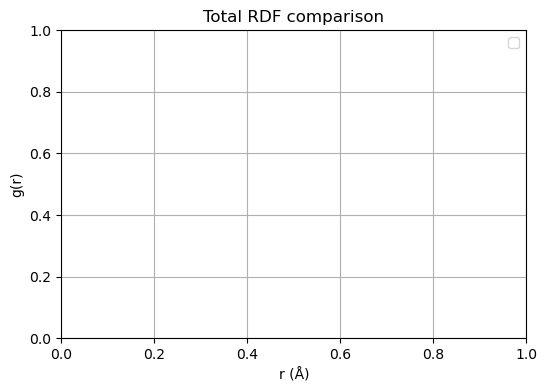

In [15]:
plt.figure()
for potid, job in rdf_jobs.items():
    traj = get_structure_trajectory(job)
    if len(traj) == 0:
        s = get_final_structure(job)
        if s is None:
            print(f"Skipping {potid}: could not load structure/trajectory.")
            continue
        traj = [s]

    r, g = compute_rdf_average(traj)
    plt.plot(r, g, label=potid)

plt.xlabel("r (Å)")
plt.ylabel("g(r)")
plt.title("Total RDF comparison")
plt.legend()
plt.show()


## 9. MSD analysis

MSD is computed from unwrapped coordinates if available.  
If only wrapped positions exist, the curve may contain jumps and should be interpreted carefully.

For current workflow development this section is still useful as an analysis scaffold.


In [16]:
def get_positions_time_series(job):
    """Try trajectory structures first; then fall back to parsed position arrays."""
    traj = get_structure_trajectory(job)
    if len(traj) > 0:
        pos = positions_from_traj(traj)
        if pos is not None:
            return pos

    # fallback names if pyiron stored arrays directly
    arr = get_array_from_job(job, ["positions", "unwrapped_positions", "wrapped_positions"])
    if arr is not None and arr.ndim == 3:
        return arr

    return None


def get_time_axis(job, n_frames):
    arr = get_array_from_job(job, ["steps", "step", "time"])
    if arr is None:
        return np.arange(n_frames)

    arr = np.asarray(arr).reshape(-1)
    if len(arr) >= n_frames:
        return arr[:n_frames]
    return np.arange(n_frames)


def compute_msd_from_positions(pos):
    ref = pos[0]
    disp = pos - ref[None, :, :]
    msd = np.mean(np.sum(disp**2, axis=2), axis=1)
    return msd


In [17]:
msd_jobs = {}
for potid in potids:
    j = find_first_finished_job(potid, TAG_ALIASES["md"])
    if j is None:
        j = find_first_finished_job(potid, TAG_ALIASES["melt_quench"])
    if j is not None:
        msd_jobs[potid] = j

print("MSD jobs:")
for potid, job in msd_jobs.items():
    print(f"  {potid:35s} -> {job.job_name}")


MSD jobs:


/var/folders/09/74gqwrwx7391krdz_my0m6r00000gn/T/ipykernel_2624/4209833548.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


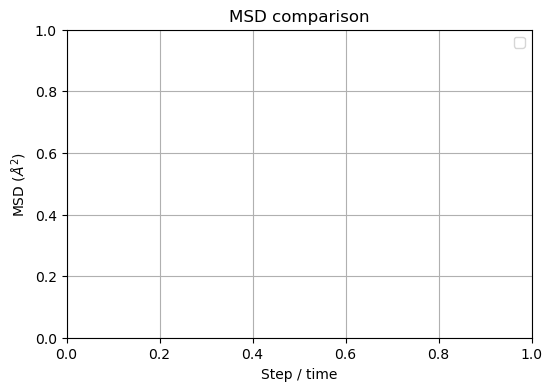

In [18]:
plt.figure()
for potid, job in msd_jobs.items():
    pos = get_positions_time_series(job)
    if pos is None:
        print(f"Skipping {potid}: positions not found.")
        continue

    if MAX_MSD_FRAMES is not None:
        pos = pos[:MAX_MSD_FRAMES]

    msd = compute_msd_from_positions(pos)
    t = get_time_axis(job, len(msd))
    plt.plot(t, msd, label=potid)

plt.xlabel("Step / time")
plt.ylabel("MSD ($\AA^2$)")
plt.title("MSD comparison")
plt.legend()
plt.show()


## 10. Energy and temperature traces

Useful for quick stability checks and for figures in the first paper.


In [19]:
def plot_trace_by_potential(job_dict, array_names, ylabel, title):
    plt.figure()
    found_any = False
    for potid, job in job_dict.items():
        arr = get_array_from_job(job, array_names)
        if arr is None:
            print(f"Skipping {potid}: {array_names} not found.")
            continue
        arr = np.asarray(arr).reshape(-1)
        plt.plot(arr, label=potid)
        found_any = True

    if found_any:
        plt.xlabel("Frame")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.show()
    else:
        plt.close()
        print(f"No arrays found for {title}.")


In [20]:
trace_jobs = msd_jobs if len(msd_jobs) > 0 else rdf_jobs

plot_trace_by_potential(
    trace_jobs,
    ["energy_pot", "energy_pot_total", "energy_tot"],
    ylabel="Energy (eV)",
    title="Potential energy trace",
)

plot_trace_by_potential(
    trace_jobs,
    ["temperature", "temperature_tot"],
    ylabel="Temperature (K)",
    title="Temperature trace",
)


No arrays found for Potential energy trace.
No arrays found for Temperature trace.


## 11. Final comparison table

This table is meant to support writing.  
You can extend it later with:
- split second-peak flags from RDF
- diffusion estimates
- stress-relaxation metrics
- NCL-specific observables


In [21]:
final_rows = []
for potid in potids:
    row = {"potid": potid}

    j_static = find_first_finished_job(potid, TAG_ALIASES["static"])
    j_md = find_first_finished_job(potid, TAG_ALIASES["md"])
    j_mq = find_first_finished_job(potid, TAG_ALIASES["melt_quench"])

    if j_static is not None:
        row["static_job"] = j_static.job_name
        row["E_static_per_atom_eV"] = energy_per_atom_from_job(j_static)

    target_job = j_mq if j_mq is not None else j_md
    if target_job is not None:
        row["analysis_job"] = target_job.job_name
        row["E_last_per_atom_eV"] = energy_per_atom_from_job(target_job)

        s = get_final_structure(target_job)
        if s is not None:
            row["N_atoms"] = len(s)
            row["Volume_A3"] = cell_volume(s)
            row["Volume_per_atom_A3"] = cell_volume(s) / len(s)

        temp = get_array_from_job(target_job, ["temperature", "temperature_tot"])
        if temp is not None:
            row["T_last_K"] = safe_float(temp[-1])

    final_rows.append(row)

final_table = pd.DataFrame(final_rows)
final_table


,potid,static_job,E_static_per_atom_eV
0,MACE,ncl05_sanity_static_B2_MACE,-4.879858


## 12. Writing notes / interpretation

Use this section as a live draft for Paper 1.

Suggested interpretation points:
- The notebook now provides a unified analysis path for all Notebook 05 outputs.
- The current DEV MACE model should be interpreted as a **workflow-validation model**, not a final production potential.
- The same notebook can later be reused for:
  - full-dataset A100 MACE
  - ACE comparison
  - larger NCL production runs


In [22]:
# Optional: save key tables for reuse in paper-writing scripts
OUTPUT_DIR = "./notebook06_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_df.csv"), index=False)
final_table.to_csv(os.path.join(OUTPUT_DIR, "final_table.csv"), index=False)

if "eos_table" in globals():
    eos_table.to_csv(os.path.join(OUTPUT_DIR, "eos_table.csv"), index=False)

print("Saved tables to:", OUTPUT_DIR)


Saved tables to: ./notebook06_outputs
